<a href="https://colab.research.google.com/github/gopikaramalingam31-ops/Gopika-capstone2-major-project-semiconductor/blob/main/capstone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Capstone Project 2 — Semiconductor Manufacturing Yield Prediction**

**Objective**: Build a classifier to predict Pass/Fail yield of a production entity, and determine whether all 591 sensor features are required.

**Dataset**: signal-data.csv — 1567 rows, 591 sensor features, 1 target (Pass/Fail: -1 = pass, 1 = fail)

**1.Importing Libraries.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [6]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**2.Export the dataset.**

In [9]:
# 1. Load and separate
df = pd.read_csv('signal-data.csv')

df.shape

(272, 592)

In [10]:
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1.0
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1.0
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1.0
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1.0
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1.0


In [11]:
print("Target distribution:")
print(df['Pass/Fail'].value_counts())
print("\nFail rate: {:.2f}%".format((df['Pass/Fail']==1).mean()*100))

Target distribution:
Pass/Fail
-1.0    232
 1.0     39
Name: count, dtype: int64

Fail rate: 14.34%


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(591), object(1)
memory usage: 1.2+ MB


In [13]:
print("Total missing values:", df.isnull().sum().sum())
missing_summary = df.isnull().mean().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(20)

Total missing values: 8063


,0
246,1.000000
244,1.000000
245,1.000000
85,1.000000
358,1.000000
382,1.000000
516,1.000000
518,1.000000
517,1.000000
109,1.000000


**3.Data cleaning.**

**steps**:


Drop the Time column (not a predictive feature, just a timestamp)
Drop columns with excessive missing values (>40%)
Drop columns that are mostly zero (>80% zeros — dead/inactive sensors)
Impute remaining missing values with the median (robust to outliers/spikes)
Drop near-zero variance columns (constant sensors carry no information)
Drop highly correlated columns (redundant sensors)


In [14]:
X = df.drop(columns=['Time', 'Pass/Fail'])
y = df['Pass/Fail']
X

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,2970.87,2610.78,2185.8111,995.3928,1.3714,100.0,102.6422,0.1218,1.5155,-0.0045,...,0.0095,173.4377,0.5022,0.0097,0.0025,1.9337,0.0165,0.0286,0.0095,173.4377
268,3087.45,2503.32,2243.7778,1502.9221,1.8160,100.0,102.0978,0.1195,1.3993,0.0042,...,NaN,NaN,0.5010,0.0199,0.0044,3.9748,0.0165,0.0286,0.0095,173.4377
269,3054.45,2443.68,2243.7778,1502.9221,1.8160,100.0,102.0978,0.1195,1.4193,0.0015,...,NaN,NaN,0.4973,0.0153,0.0038,3.0703,0.0165,0.0286,0.0095,173.4377
270,2988.52,2291.92,2183.5777,1764.5386,1.7050,100.0,100.4478,0.1222,1.4305,0.0001,...,0.0046,51.9067,0.4999,0.0095,0.0028,1.9072,0.0274,0.0142,0.0046,51.9067


In [15]:
X.isnull().mean().sort_values(ascending = False).head(10)

,0
244,1.0
358,1.0
384,1.0
383,1.0
382,1.0
518,1.0
516,1.0
517,1.0
492,1.0
109,1.0


**3.1 Drop columns with too much missing data (>40%)**


In [16]:
missing_pct = X.isnull().mean()
drop_missing = missing_pct[missing_pct > 0.4].index
drop_missing

Index(['85', '109', '110', '111', '157', '158', '220', '244', '245', '246',
       '292', '293', '358', '382', '383', '384', '492', '516', '517', '518',
       '578', '579', '580', '581'],
      dtype='object')

In [17]:
X = X.drop(columns=drop_missing)
print(f"Dropped {len(drop_missing)} cols for high missingness -> {X.shape[1]} remain")

Dropped 24 cols for high missingness -> 566 remain


**3.2 Drop columns that are mostly zero (>80%)**



In [18]:
zero_pct = (X == 0).mean()
zero_pct

,0
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
585,0.000000
586,0.000000
587,0.000000
588,0.000000


In [19]:
drop_zero = zero_pct[zero_pct > 0.8].index
drop_zero

Index(['13', '52', '74', '97', '114', '141', '149', '178', '179', '186',
       ...
       '529', '530', '531', '532', '533', '534', '535', '536', '537', '538'],
      dtype='object', length=122)

In [20]:
print(len(drop_zero))

122


In [21]:
X = X.drop(columns=drop_zero)
print(f"Dropped {len(drop_zero)} cols for excess zeros -> {X.shape[1]} remain")

Dropped 122 cols for excess zeros -> 444 remain


**3.3 Fill remaining na values with median.**

In [22]:
X = X.fillna(X.median())
X

,0,1,2,3,4,5,6,7,8,9,...,576,577,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,1.6765,14.9509,0.5005,0.0118,0.0035,2.3630,0.0184,0.0160,0.00515,84.4337
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,1.1065,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.00600,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,2.0952,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.01480,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,1.7585,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.00440,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,1.6597,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.00440,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,2970.87,2610.78,2185.8111,995.3928,1.3714,100.0,102.6422,0.1218,1.5155,-0.0045,...,1.3122,12.0001,0.5022,0.0097,0.0025,1.9337,0.0165,0.0286,0.00950,173.4377
268,3087.45,2503.32,2243.7778,1502.9221,1.8160,100.0,102.0978,0.1195,1.3993,0.0042,...,1.9756,12.5144,0.5010,0.0199,0.0044,3.9748,0.0165,0.0286,0.00950,173.4377
269,3054.45,2443.68,2243.7778,1502.9221,1.8160,100.0,102.0978,0.1195,1.4193,0.0015,...,1.4021,9.0446,0.4973,0.0153,0.0038,3.0703,0.0165,0.0286,0.00950,173.4377
270,2988.52,2291.92,2183.5777,1764.5386,1.7050,100.0,100.4478,0.1222,1.4305,0.0001,...,1.8497,18.4482,0.4999,0.0095,0.0028,1.9072,0.0274,0.0142,0.00460,51.9067


**3.4 Drop near-zero variance columns**

In [23]:
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)
X_var

array([[3.0309300e+03, 2.5640000e+03, 2.1877333e+03, ..., 1.4950900e+01,
        2.3630000e+00, 8.4433700e+01],
       [3.0957800e+03, 2.4651400e+03, 2.2304222e+03, ..., 1.0900300e+01,
        4.4447000e+00, 2.0820450e+02],
       [2.9326100e+03, 2.5599400e+03, 2.1864111e+03, ..., 9.2721000e+00,
        3.1745000e+00, 8.2860200e+01],
       ...,
       [3.0544500e+03, 2.4436800e+03, 2.2437778e+03, ..., 9.0446000e+00,
        3.0703000e+00, 1.7343770e+02],
       [2.9885200e+03, 2.2919200e+03, 2.1835777e+03, ..., 1.8448200e+01,
        1.9072000e+00, 5.1906700e+01],
       [3.0332900e+03, 2.5872700e+03, 2.2441111e+03, ..., 1.3528600e+01,
        2.7605000e+00, 8.4433700e+01]])

In [24]:
X = pd.DataFrame(X_var, columns=X.columns[selector.get_support()])
X

,0,1,2,3,4,6,12,14,15,16,...,569,570,571,572,573,574,576,577,585,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,202.4396,7.9558,414.8710,10.0433,...,19.0012,533.8500,2.1113,8.95,0.3157,3.0624,1.6765,14.9509,2.3630,84.4337
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,200.5470,10.1548,414.7347,9.2599,...,19.0012,535.0164,2.4335,5.92,0.2653,2.0111,1.1065,10.9003,4.4447,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,202.0179,9.5157,416.7075,9.3144,...,68.8489,535.0245,2.0293,11.21,0.1882,4.0923,2.0952,9.2721,3.1745,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,201.8482,9.6052,422.2894,9.6924,...,25.0363,530.5682,2.0253,9.33,0.1738,2.8971,1.7585,8.5831,2.0544,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,201.9424,10.5661,420.5925,10.3387,...,19.0012,532.0155,2.0275,8.83,0.2224,3.1776,1.6597,10.9698,99.3032,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,2970.87,2610.78,2185.8111,995.3928,1.3714,102.6422,199.9475,6.8120,409.1550,9.6162,...,18.0015,531.1618,1.7323,6.97,0.2079,2.5969,1.3122,12.0001,1.9337,173.4377
268,3087.45,2503.32,2243.7778,1502.9221,1.8160,102.0978,202.2886,9.8855,423.9415,9.4102,...,19.0012,531.4909,2.3698,10.50,0.2966,3.3302,1.9756,12.5144,3.9748,173.4377
269,3054.45,2443.68,2243.7778,1502.9221,1.8160,102.0978,201.6701,10.7648,419.0930,10.0212,...,19.0012,529.9355,2.1598,7.43,0.1953,2.6491,1.4021,9.0446,3.0703,173.4377
270,2988.52,2291.92,2183.5777,1764.5386,1.7050,100.4478,199.9116,7.0778,410.3098,9.6388,...,19.0012,534.1545,1.6889,9.88,0.3116,3.4917,1.8497,18.4482,1.9072,51.9067


In [25]:
print(f"After variance threshold -> {X.shape[1]} remain")

After variance threshold -> 294 remain


**3.5 Drop highly correlated columns (keep one of each pair above 0.95)**

In [35]:
corr_matrix = X.corr().abs()
corr_matrix

,0,1,2,3,4,6,12,14,15,16,...,559,562,564,569,570,571,572,573,585,589
0,1.000000,0.001956,0.077782,0.008385,0.007556,0.035827,0.128592,0.112054,0.053412,0.085365,...,0.101756,0.023627,0.124596,0.019412,0.017656,0.055618,0.065552,0.010222,0.046447,0.059165
1,0.001956,1.000000,0.011842,0.073694,0.051426,0.057726,0.035811,0.060306,0.054928,0.032078,...,0.075489,0.006612,0.084926,0.100505,0.037318,0.023109,0.053637,0.002307,0.010459,0.064800
2,0.077782,0.011842,1.000000,0.273644,0.120298,0.090637,0.037643,0.028059,0.077188,0.161336,...,0.032488,0.009043,0.097115,0.014656,0.074651,0.074599,0.004463,0.088835,0.058554,0.090573
3,0.008385,0.073694,0.273644,1.000000,0.464754,0.559746,0.086879,0.076721,0.005279,0.092816,...,0.095724,0.016306,0.041031,0.037983,0.038386,0.070303,0.012227,0.008970,0.001100,0.069568
4,0.007556,0.051426,0.120298,0.464754,1.000000,0.199055,0.056392,0.029559,0.073996,0.105326,...,0.044717,0.025426,0.070924,0.041130,0.019811,0.005150,0.024129,0.045549,0.058477,0.034929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,0.055618,0.023109,0.074599,0.070303,0.005150,0.058878,0.001230,0.054558,0.112227,0.028462,...,0.015604,0.134816,0.099557,0.111002,0.069757,1.000000,0.163801,0.060246,0.029841,0.029679
572,0.065552,0.053637,0.004463,0.012227,0.024129,0.064523,0.060692,0.039365,0.033061,0.004150,...,0.038689,0.045935,0.021561,0.016775,0.499413,0.163801,1.000000,0.755979,0.010218,0.053243
573,0.010222,0.002307,0.088835,0.008970,0.045549,0.071992,0.004474,0.067780,0.024771,0.044368,...,0.076009,0.022301,0.070873,0.024689,0.411435,0.060246,0.755979,1.000000,0.034154,0.060081
585,0.046447,0.010459,0.058554,0.001100,0.058477,0.030203,0.031788,0.021370,0.044059,0.040907,...,0.031741,0.001665,0.013459,0.026930,0.009344,0.029841,0.010218,0.034154,1.000000,0.022259


In [36]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
upper

,0,1,2,3,4,6,12,14,15,16,...,559,562,564,569,570,571,572,573,585,589
0,NaN,0.001956,0.077782,0.008385,0.007556,0.035827,0.128592,0.112054,0.053412,0.085365,...,0.101756,0.023627,0.124596,0.019412,0.017656,0.055618,0.065552,0.010222,0.046447,0.059165
1,NaN,NaN,0.011842,0.073694,0.051426,0.057726,0.035811,0.060306,0.054928,0.032078,...,0.075489,0.006612,0.084926,0.100505,0.037318,0.023109,0.053637,0.002307,0.010459,0.064800
2,NaN,NaN,NaN,0.273644,0.120298,0.090637,0.037643,0.028059,0.077188,0.161336,...,0.032488,0.009043,0.097115,0.014656,0.074651,0.074599,0.004463,0.088835,0.058554,0.090573
3,NaN,NaN,NaN,NaN,0.464754,0.559746,0.086879,0.076721,0.005279,0.092816,...,0.095724,0.016306,0.041031,0.037983,0.038386,0.070303,0.012227,0.008970,0.001100,0.069568
4,NaN,NaN,NaN,NaN,NaN,0.199055,0.056392,0.029559,0.073996,0.105326,...,0.044717,0.025426,0.070924,0.041130,0.019811,0.005150,0.024129,0.045549,0.058477,0.034929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.163801,0.060246,0.029841,0.029679
572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.755979,0.010218,0.053243
573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.034154,0.060081
585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022259


In [37]:
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
len(to_drop)

0

In [38]:
X = X.drop(columns=to_drop)
print(f"Dropped {len(to_drop)} highly correlated cols -> {X.shape[1]} remain")

Dropped 0 highly correlated cols -> 194 remain


**4.Data analysis and Visualization**

**4.1 Univariant analysis.**

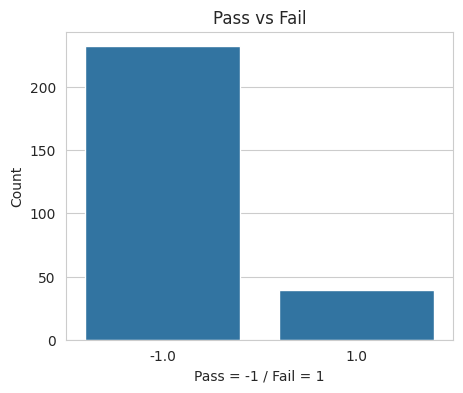

In [39]:
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Pass vs Fail")
plt.xlabel("Pass = -1 / Fail = 1")
plt.ylabel("Count")
plt.show()

**Distribution of few sample sensor reading**

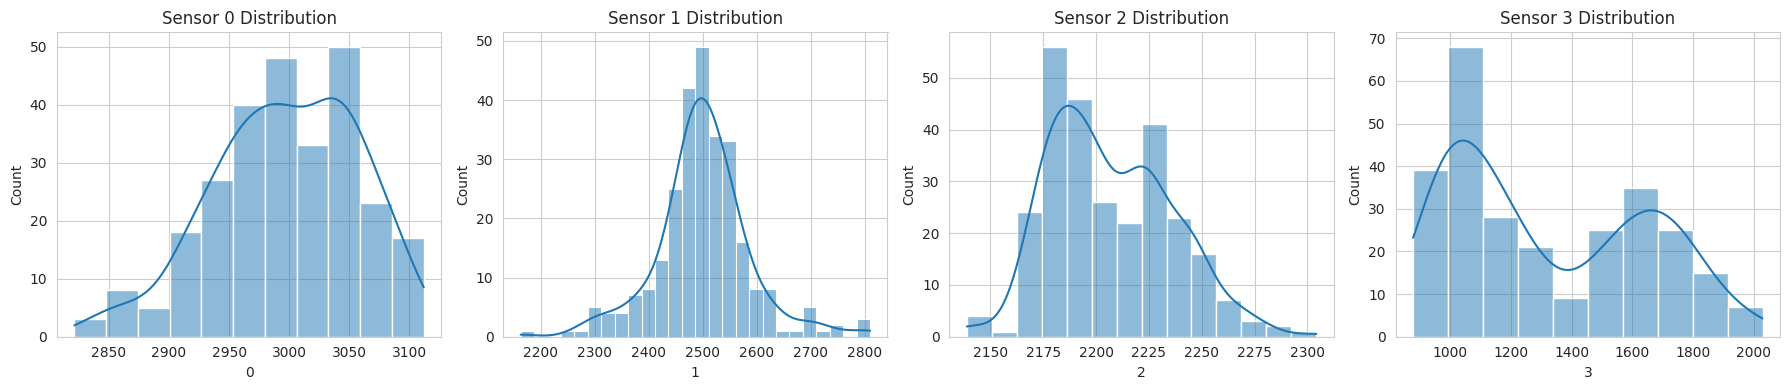

In [40]:
sample_colm = X.columns[0:5]
fig,axes = plt.subplots(1 , 4, figsize=(18,4))
for ax,col in zip(axes , sample_colm):
    sns.histplot(X[col],kde=True,ax=ax)
    ax.set_title(f'Sensor {col} Distribution')
plt.tight_layout()
plt.show()

**4.2 Bivariant analysis**

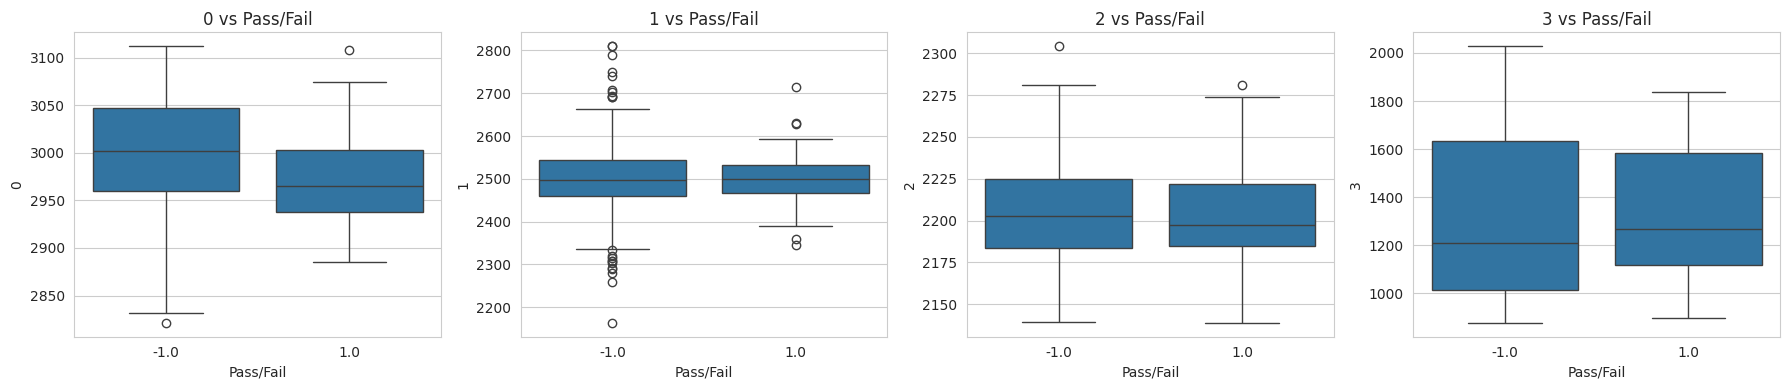

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, sample_colm):
    sns.boxplot(x=y, y=X[col], ax=ax)
    ax.set_title(f'{col} vs Pass/Fail')
plt.tight_layout()
plt.show()

**4.3 Multivariant analysis**

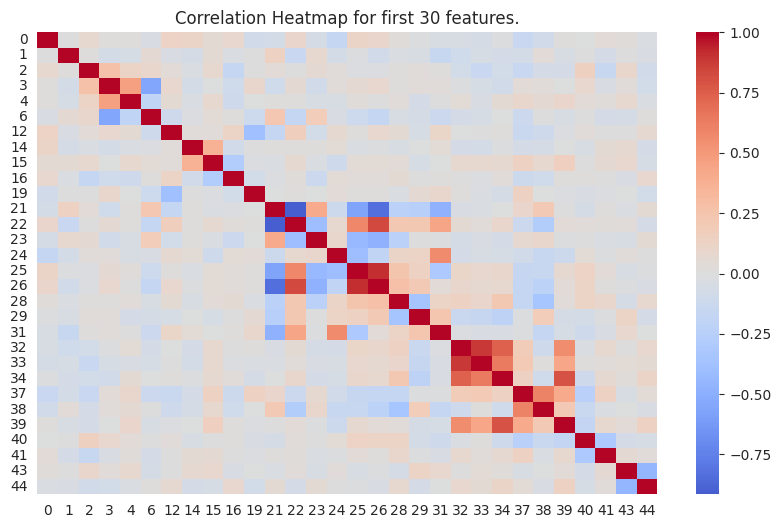

In [42]:
plt.figure(figsize=(10,6))
sns.heatmap(X.iloc[:, :30].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap for first 30 features.')
plt.show()

**5.Data Pre-processing.**

In [44]:
nan_indices = y[y.isna()].index
X_cleaned = X.drop(nan_indices)
y_cleaned = y.drop(nan_indices)

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned, test_size=0.2, stratify=y_cleaned, random_state=42
)

In [45]:
print("Shape of train:",X_train.shape,"Shape of test:",X_test.shape)
print("Train balance\n",y_train.value_counts(normalize=True))
print("Test balance\n",y_test.value_counts(normalize=True))

Shape of train: (216, 194) Shape of test: (55, 194)
Train balance
 Pass/Fail
-1.0    0.856481
 1.0    0.143519
Name: proportion, dtype: float64
Test balance
 Pass/Fail
-1.0    0.854545
 1.0    0.145455
Name: proportion, dtype: float64


In [46]:
comparision = pd.DataFrame({
    "Original_mean":X.mean(),
    "Train_mean":X_train.mean(),
    "Test_mean":X_test.mean()
})
comparision.head()

,Original_mean,Train_mean,Test_mean
0,2997.337904,2997.800880,2994.866000
1,2500.929118,2502.994815,2491.246727
2,2206.750488,2204.865430,2213.474342
3,1323.999275,1298.232759,1418.778093
4,1.290880,1.282837,1.329218


In [47]:
print("Max mean difference of (train vs original):" ,(comparision["Original_mean"]-comparision["Train_mean"]).max())
print("Max mean difference of (test vs original):" ,(comparision["Original_mean"]-comparision["Test_mean"]).max())

Max mean difference of (train vs original): 133.9216479030501
Max mean difference of (test vs original): 351.53175133689865


In [48]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)
X_train_scaled

array([[-0.4130354 , -0.87651984, -0.49648795, ...,  0.55357485,
        -0.09750195,  0.16154351],
       [ 0.66705877,  0.23126666,  2.37909556, ..., -0.29902446,
        -0.12619035, -0.84726598],
       [-0.13488185, -1.69677518, -0.28352678, ...,  1.01227122,
        -0.15940135, -1.00345529],
       ...,
       [-0.14544673,  1.28407495,  0.62742041, ..., -0.49237629,
        -0.0367935 ,  1.24440787],
       [ 1.55021693,  0.5639585 ,  0.9980908 , ..., -0.72069601,
        -0.12810492, -0.75351099],
       [ 0.01302651,  0.68815036, -0.68988179, ..., -0.61270695,
        -0.26535094, -0.45644768]])

In [49]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [50]:
importance = pd.Series(rf.feature_importances_,index = X.columns)
importance

,0
0,0.008541
1,0.003015
2,0.003936
3,0.006209
4,0.006512
...,...
571,0.004663
572,0.002852
573,0.003974
585,0.006261


In [51]:
top_60 = importance.sort_values(ascending=False)
top_60_cols = top_60.index.tolist()

In [52]:
print("The final selected feature count:",len(top_60_cols))
print("Top 10 most importance sensors:")
print(top_60.head(10))

The final selected feature count: 194
Top 10 most importance sensors:
122    0.017458
336    0.013658
345    0.013638
333    0.013431
484    0.011781
115    0.011224
200    0.010995
205    0.010574
29     0.010546
270    0.010273
dtype: float64


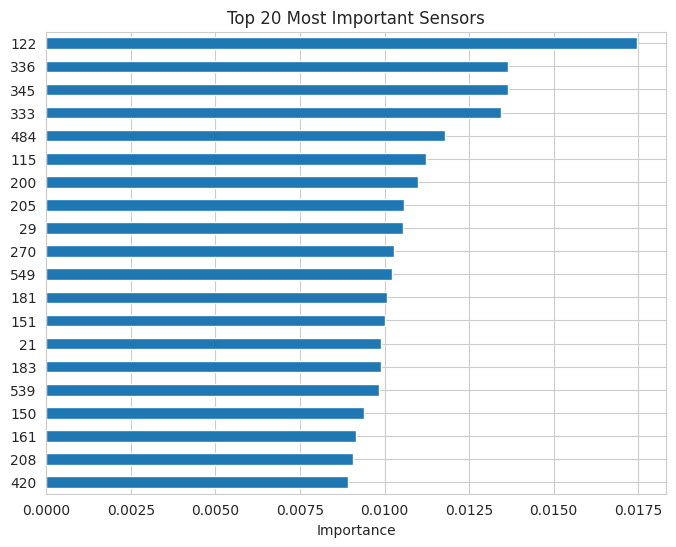

In [53]:
plt.figure(figsize=(8,6))
top_60.head(20).sort_values().plot(kind='barh')
plt.title('Top 20 Most Important Sensors')
plt.xlabel('Importance')
plt.show()

In [54]:
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)[top_60_cols].values
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)[top_60_cols].values
X_train_final

array([[-0.021192  , -0.8182012 , -0.19284918, ..., -0.07843913,
         0.76786593, -0.0437565 ],
       [-0.69028503,  0.03571047,  0.13818185, ..., -0.03762811,
        -0.81861285, -0.0437565 ],
       [ 0.51981268, -1.37099301, -0.11534399, ..., -0.12866808,
        -0.81861285, -0.0437565 ],
       ...,
       [ 0.54846402,  0.02836946, -0.2313786 , ..., -0.3766735 ,
        -0.81861285, -0.0437565 ],
       [-0.8284856 ,  0.21314126, -0.29163563, ..., -0.05646396,
         2.19273797, -0.0437565 ],
       [ 2.27260046,  0.79848282, -0.02999582, ..., -0.34528041,
         0.42620074, -0.0437565 ]])

In [55]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_final, y_train)
print("\nBefore SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())


Before SMOTE: {-1.0: 185, 1.0: 31}
After SMOTE: {-1.0: 185, 1.0: 185}


**6.Model Training , Testing & Tuning.**

**6.1 Random Forest.**

In [56]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_bal, y_train_bal)

rf_best = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

rf_train_pred = rf_best.predict(X_train_bal)
rf_test_pred = rf_best.predict(X_test_final)

print("\nTrain Accuracy:", accuracy_score(y_train_bal, rf_train_pred))
print("Test Accuracy:", accuracy_score(y_test, rf_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, rf_test_pred))

Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Train Accuracy: 1.0
Test Accuracy: 0.8363636363636363

Test Classification Report:
              precision    recall  f1-score   support

        -1.0       0.85      0.98      0.91        47
         1.0       0.00      0.00      0.00         8

    accuracy                           0.84        55
   macro avg       0.43      0.49      0.46        55
weighted avg       0.73      0.84      0.78        55



**6.2 Support vector machine.**

In [57]:
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm = SVC(random_state=42)
svm_grid = GridSearchCV(svm, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_bal, y_train_bal)

svm_best = svm_grid.best_estimator_
print("Best SVM params:", svm_grid.best_params_)

svm_train_pred = svm_best.predict(X_train_bal)
svm_test_pred = svm_best.predict(X_test_final)

print("\nTrain Accuracy:", accuracy_score(y_train_bal, svm_train_pred))
print("Test Accuracy:", accuracy_score(y_test, svm_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, svm_test_pred))

Best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Train Accuracy: 1.0
Test Accuracy: 0.8545454545454545

Test Classification Report:
              precision    recall  f1-score   support

        -1.0       0.85      1.00      0.92        47
         1.0       0.00      0.00      0.00         8

    accuracy                           0.85        55
   macro avg       0.43      0.50      0.46        55
weighted avg       0.73      0.85      0.79        55



**6.3 Naive bayes.**

In [58]:
nb = GaussianNB()
nb.fit(X_train_bal, y_train_bal)

nb_train_pred = nb.predict(X_train_bal)
nb_test_pred = nb.predict(X_test_final)

print("Train Accuracy:", accuracy_score(y_train_bal, nb_train_pred))
print("Test Accuracy:", accuracy_score(y_test, nb_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, nb_test_pred))

Train Accuracy: 0.8189189189189189
Test Accuracy: 0.5636363636363636

Test Classification Report:
              precision    recall  f1-score   support

        -1.0       0.85      0.60      0.70        47
         1.0       0.14      0.38      0.20         8

    accuracy                           0.56        55
   macro avg       0.49      0.49      0.45        55
weighted avg       0.74      0.56      0.63        55



**7.Model Comparision**

In [59]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Naive Bayes'],
    'Train Accuracy': [
        accuracy_score(y_train_bal, rf_train_pred),
        accuracy_score(y_train_bal, svm_train_pred),
        accuracy_score(y_train_bal, nb_train_pred)
    ],
    'Test Accuracy': [
        accuracy_score(y_test, rf_test_pred),
        accuracy_score(y_test, svm_test_pred),
        accuracy_score(y_test, nb_test_pred)
    ],
    'Test F1 (fail class)': [
        f1_score(y_test, rf_test_pred, pos_label=1),
        f1_score(y_test, svm_test_pred, pos_label=1),
        f1_score(y_test, nb_test_pred, pos_label=1)
    ]
})
results

,Model,Train Accuracy,Test Accuracy,Test F1 (fail class)
0,Random Forest,1.000000,0.836364,0.0
1,SVM,1.000000,0.854545,0.0
2,Naive Bayes,0.818919,0.563636,0.2


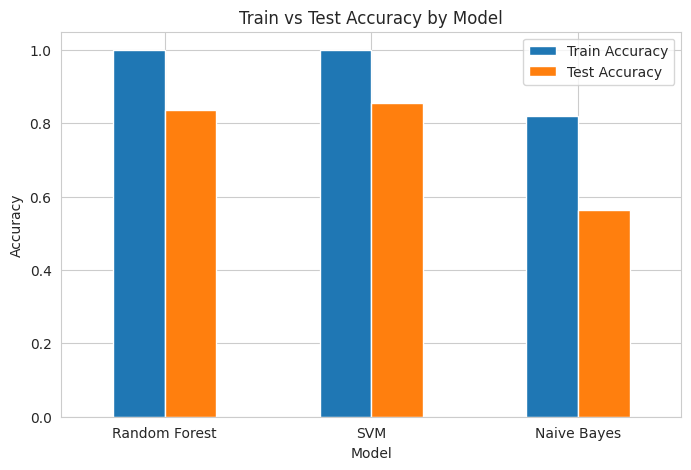

In [60]:
results.set_index('Model')[['Train Accuracy','Test Accuracy']].plot(kind='bar', figsize=(8,5))
plt.title('Train vs Test Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.ylim(0,1.05)
plt.show()

In [61]:
final_model = rf_best
joblib.dump(final_model, 'best_model.pkl')
joblib.dump(scalar, 'scaler.pkl')
joblib.dump(top_60_cols, 'top_60_features.pkl')
print("Saved: best_model.pkl, scaler.pkl, top_60_features.pkl")

Saved: best_model.pkl, scaler.pkl, top_60_features.pkl


**7. Conclusion & Improvisation**

**Summary of approach:**
* 590 raw sensor features down to 60 through a layered pipeline: missingness filtering, zero-dominance filtering, variance thresholding, correlation filtering, and Random Forest importance ranking.

* Addressed severe class imbalance (~93/7 split) using SMOTE applied only to training data, preserving an honest, untouched test set

* Compared 3 models — Random Forest, SVM, and Naive Bayes — using F1-score on the fail class as the primary metric rather than accuracy.


**Key takeaways (fill in after running):**

* Which model performed best, and by how much?

* Which sensors emerged as most important, and does that align with any known process knowledge?

* Not all 591 original features were necessary — a much smaller, targeted subset captured most of the predictive signal.

**Possible improvements:**

* Try additional feature selection techniques (e.g., Recursive Feature Elimination, L1-regularized Logistic Regression) to cross-validate which sensors matter.

* Experiment with ensemble/stacking of multiple models.

* Collect more fail-case examples over time to reduce reliance on synthetic (SMOTE) samples.

* Investigate misclassified fail cases to understand what patterns the model is missing.


****